Estudiante: Elmer Hernán Barquero Chaves C10896

# Parte I : Memoría compartida

Sin realizar cambio alguno sobre el archovo `mandelbrot.cpp`, se obtiene:

![Screenshot from 2025-02-25 13-53-40.png](<attachment:Screenshot from 2025-02-25 13-53-40.png>)


Se adjunta los comandos usados para facilidad de copiado


```bash
	g++ mandelbrot.cpp -o mandelbrot.x
	./mandelbrot.x 
```
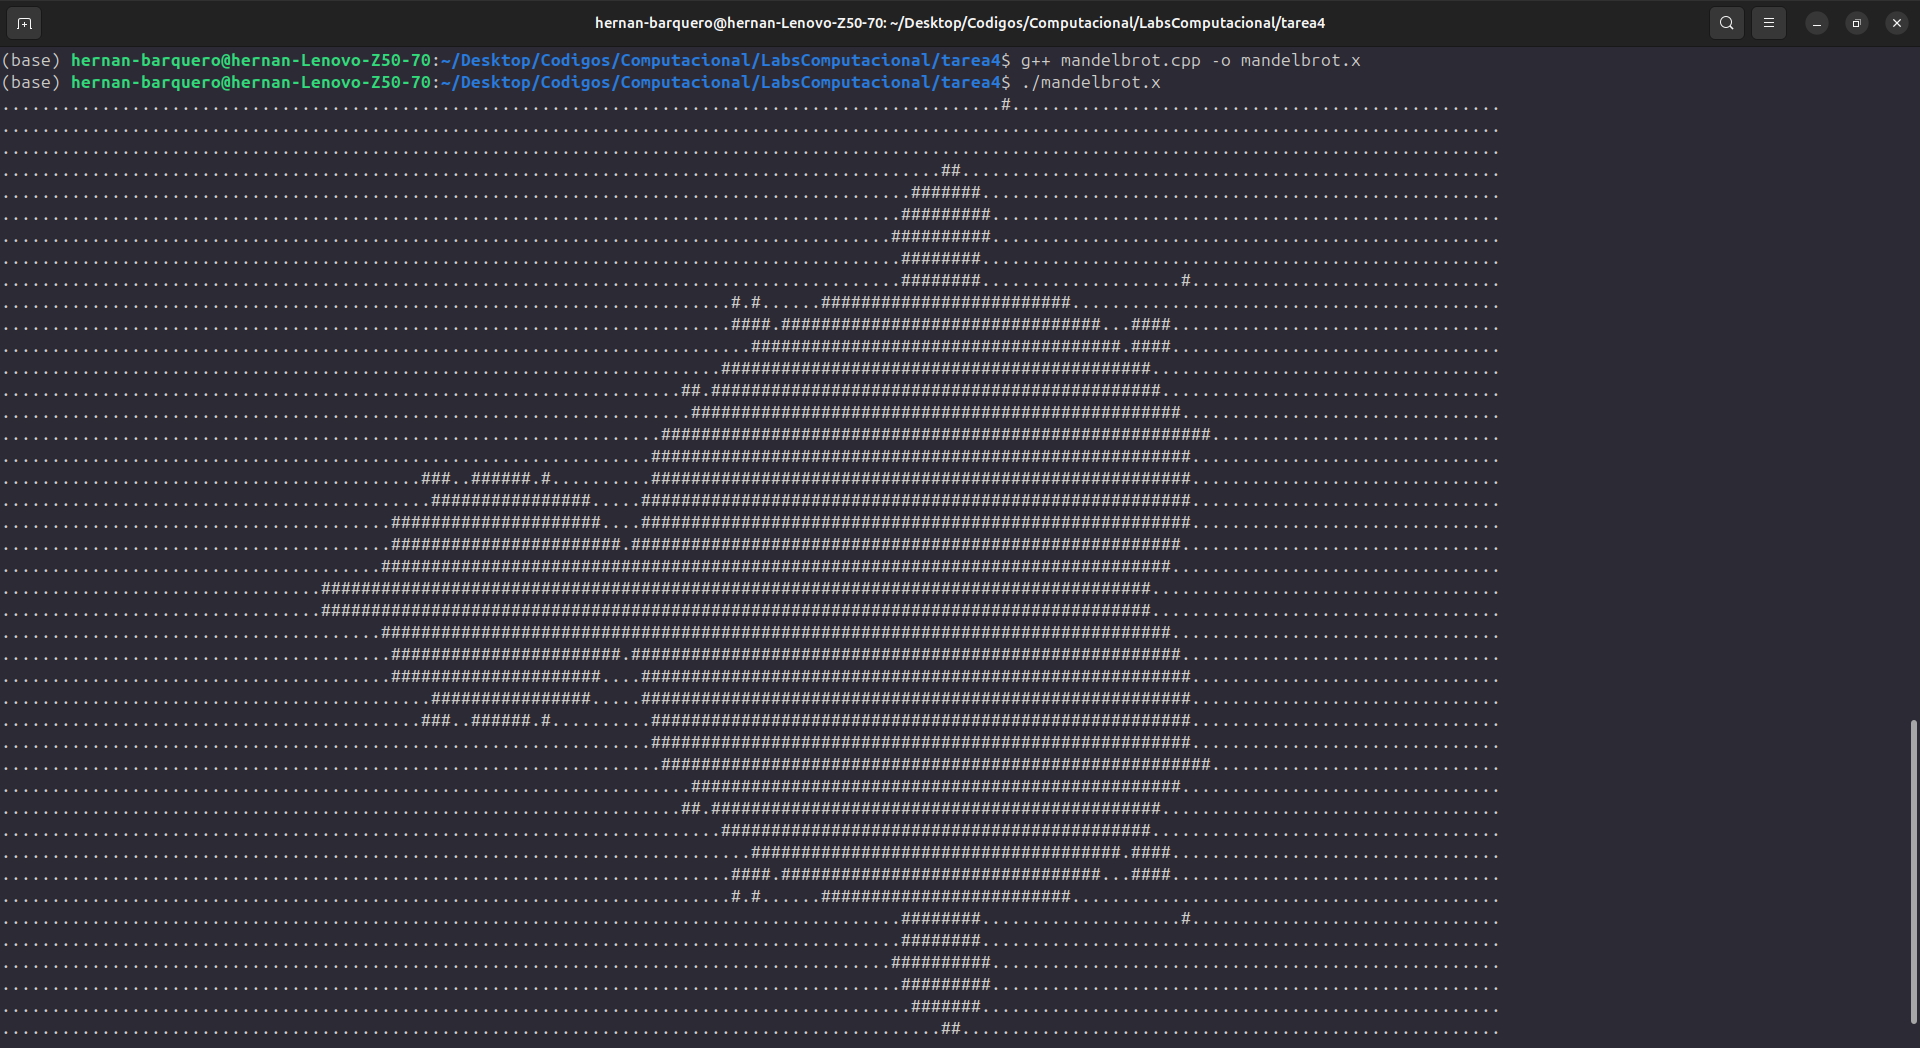

## Análisis del código original

El código original presenta dos funciones `main` como es de constumbre en c++  y `mandelbrot`, a continuación se detalla el funcionamiento de cada una de ellas:

* `main`:

	- El `main` se inicializa como una función que devuelve en *int*. Primeramente, se establecen los parámetros en los que se desarrollara el programa, es decir, el ancho y alto de caracteres que se utilizaran para generar el espacio (150x45), luego un número máximo de iteraciones a realizar (Relacionado a la función `mandelbrot`) y por último, se establecen los límites reales e imaginarios superiores e inferiores (Realacionados a la función `mandelbrot`).

	- Seguidamente, comienza el recorrido **punto por punto** del espacio a generar en pantalla (Ver Imagen anterior), esto se realiza con dos `for loops` y se recorre desde x,y = 0 hasta x , y menor al parametro de ancho y altura, respectivamente; avanzado de uno en uno. Para cada elemento del ciclo, se les inicia como un número complejo utilizando la funcionalidad de `std::complex<double>`. Estos números complejos se les otorga un valor específico para cada punto del espacio de acuerdo a las formulas colocadas en el constructor. 

	- Posteriormente, se le pasa el número complejo a la función de `mandelbrot`, junto al número máximo de iteraciones, para que el resultado pase por unos condiconales y dependiendo del valor que devuelva dicha función, se genere un "#" o un "." en el espacio de la terminal.

* `mandelbrot`:
	- Es una función inicializada como int, que requiere de dos argumentos, uno de tipo `std::complex<double>` y un int, ambos argumentos se mantienen constantes y se pasan como referencias.

	- Esta función se encarga de evaluar el número complejo iterativamente, haciendo las composiones requiridas por el conjunto de Mandelbrot (Eq 1 del enunciado). Bajo la condición de que la norma de dicho número complejo sea menor a 2 en cada iteración y que además, el iterador que utiliza, sea menor valor valor máximo que se le asignó. Esto lo realiza por medio de un `while`, el uso este y la composición se muestran al final:

	- Finalmente, esta función devuelve el valor del iterador n cuando la condición del ciclo no se cumple.

```c++
	while(abs(z) <= 2 && n < maxits){
    	z = z * z + c;
    	++n;
  	}
```
	

## Implemantación de la paralelización usando OpenMP con memoria compartida

Como se mencionó en la sección anterior, la función original `main` recorre **uno por uno** los puntos del espacio que va a utilizar y en cada uno de ellos, genera un número complejo, se lo pasa a la función `mandelbrot` y por último pasa por los condicionales para dar como resultado un "#" o un "." en la terminal.

Es posible paralalelizar el primero de los `for loops`, de modo que se realicen los calculos de todos los puntos de forma paralela. No obstante, como se ha visto en clase, ese tipo de comportamiento da problemas a la hora de realizar operaciones como los `std::cout`, ya que se pueden mostrar en desorden. Por lo que es necesario realizar ciertos cambios para controlar la forma en que se da el output.
Para cumplir con lo anterior se va a utilizar: 

Se va a utilizar un vector de vectores para que va a contener caracteres como un artificio para alamacenar los resultados de cada uno de los puntos del espacio en el orden correspondiente:

```c++
std::vector<std::vector<char>> grap(height, std::vector<char>(width));
```
Al usar esto, se requerian de otros cambios a la hora de guardar (en es implementación) y imprimir los resultados (Implementación original), por lo que se procedió a hacer los siguiente:

```c++
#pragma omp parallel for// <------- Cambio para paralelización: Se hace la paralelización 
for(int y = 0; y < height; ++y){
    for(int x = 0; x < width; ++x){
    	// Mapeo de pixeles a número complejo
        std::complex<double> c( minX + (maxX - minX) * x / width,
                                minY + (maxY - minY) * y / height );
  
        // Cálculo del número de iteraciones
        int n = mandelbrot(c, max_iter);
  
        // Se guardan los resultados en los puntos discretizados de una malla que simboliza el espacio de la grafica
        if(n == max_iter){
          grap[y][x] = '#';
        } else{
          grap[y][x] = '.';
        }
      }
    }
```
En el extracto anterior, se observa la paralelización y como se llena la variable `grap` con los resultados correspondientes a cada punto.

Para concluir, es necesario imprimir el resultado y con los cambios realizados, hay que generar una nueva forma de imprimirlos. Sería la dada a continuación:

```c++
for(int y = 0; y < height; ++y){
    for(int x = 0; x < width; ++x){
      std::cout << grap[y][x];
    }
    std::cout << std::endl;
  }
Es decir, que luego de la paralelización, es necesario recorrer punto a punto `grap` e ir imprimiendo uno a uno los resultados para obtener el gráfico correspondiente.
```

# Parte II: Memoria Distribuida

## Inicialización del entorno MPI

Se realizó a justo como en las lecciones

```c++
// Inicializando el ambiente MPI
int size, rank;
MPI_Init(&argc, &argv);

// Tamaño y rango
MPI_Comm_size(MPI_COMM_WORLD, &size); // Número total de procesos
MPI_Comm_rank(MPI_COMM_WORLD, &rank);  // Identificador del proceso
    
const int N = 1000; // Tamaño de los vectores
```

## Generación y llenado de los vectores

```c++
// Se declaron los 4 vectores a utilizar
std::vector<double> a, b, local_a, local_b; 
// Se llenan los vectores a y b
if (rank == 0) {
    // Inicio los vectores en el proceso 0
    a.resize(N); 
    b.resize(N);
    for (int i = 0; i < N; ++i) {
        a[i] = b[i] = i + 1; // a = [1,2,3,...] y b = [1,2,3,...]
    }
}

// Asignación local de memoria
int nlocal = N / size; // Tamaño de los vectores locales
local_a.resize(nlocal);
local_b.resize(nlocal);
```
Aún no se llenan los local_a y local_b

## Función MPI_Scatter

En general, lo que realiza la función es agarrar los datos que se encuentran en el proceso 0 o raíz y los distribuye a todos los otros procesos de forma equitativa. En el caso de este `dot_product.cpp`, lo que realiza es lo siguiente:

Toma el contenido de los vectores a y b desde el proceso 0, divide el contenido de ambos en partes iguales y los envia a cada proceso. Todos los procesos reciben cierta cantidad definida de elementos (nlocal) y los guarda en los vectores local_a y local_b.


```c++
// Distribución de secciones de los vectores a cada proceso
MPI_Scatter(a.data(), nlocal, MPI_DOUBLE, local_a.data(), nlocal, MPI_DOUBLE, 0, MPI_COMM_WORLD);
MPI_Scatter(b.data(), nlocal, MPI_DOUBLE, local_b.data(), nlocal, MPI_DOUBLE, 0, MPI_COMM_WORLD);
```
donde cada entrada representa lo siguiente:

* x.data(): Buffer de envíos

* nlocal: Número de elementos para cada proceso

* MPI:INT: Tipo de datos a enviar

* nlocal: Número de datos a recibir de cada proceso

* MPI:INT: Tipo de datos a recibir

* 0: Rango del proceso 0

*  MPI_COMM_WORLD: Comunicador

## Realización de los cálculos por proceso

```c++
// Distribución de secciones de los vectores a cada proceso
double local_dot = 0.0;
// Calculando el producto punto local
for (int i = 0; i < nlocal; ++i) {
    local_dot += local_a[i] * local_b[i];
}
```

## Se devuelve todo al proceso 0

```c++
double global_dot = 0.0;
// Reduce los productos locales al proceso raíz para obtener el producto punto global
MPI_Reduce(&local_dot, &global_dot, 1, MPI_DOUBLE, MPI_SUM, 0, MPI_COMM_WORLD);
```

## Se imprime el resultado y se cierra MPI

```c++
if (rank == 0) {
    // Imprimiendo en el proceso 0 el resultado
    std::cout << "a*b = : " << global_dot << std::endl;
}

// Cierro el entorno MPI
MPI_Finalize();
return 0;
```